# NB00 - Preparacion de datos y analisis exploratorio

**Objetivos de aprendizaje**

- Construir una version binaria de Iris con `versicolor` y `virginica`.
- Justificar por que `setosa` se excluye de este curso.
- Explorar visualmente distribuciones, relaciones bivariadas y correlaciones.
- Crear un split train/test estratificado y versiones escaladas.
- Guardar los splits compartidos que usaran todos los notebooks posteriores.

**Referencias de este notebook**

- Hosmer, Lemeshow & Sturdivant (2013): guia la practica aplicada de inspeccionar datos, definir la respuesta binaria, separar train/test y preparar variables antes de ajustar modelos logisticos.


In [1]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Los notebooks pueden ejecutarse desde la raiz del repo o desde notebooks/.
# Este bloque localiza la raiz y agrega src/ al path de importacion.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils import (
    COLOR_PALETTE,
    RANDOM_STATE,
    get_train_test_split,
    load_binary_iris,
    load_processed_splits,
    plot_coefficients,
    plot_decision_boundary,
    plot_regularization_path,
    plot_sigmoid,
    save_processed_splits,
    set_plot_style,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
set_plot_style()
np.random.seed(RANDOM_STATE)

DATA_DIR = PROJECT_ROOT / "data" / "processed"


## 1. Carga de Iris y definicion del problema

Iris contiene 150 flores, cuatro variables morfologicas medidas en centimetros y tres especies originales: setosa, versicolor y virginica. Para estudiar regresion logistica binaria nos quedamos con dos clases que se solapan parcialmente.


In [2]:
# Cargamos la version binaria definida en src/utils.py para garantizar
# que todos los notebooks usen exactamente la misma convencion.
X, y = load_binary_iris()

resumen = pd.DataFrame(
    {
        "observaciones": [len(X)],
        "features": [X.shape[1]],
        "clase_positiva": ["virginica = 1"],
        "clase_negativa": ["versicolor = 0"],
    }
)
display(resumen)
display(y.value_counts().rename(index={0: "versicolor", 1: "virginica"}).to_frame("conteo"))
display(X.head())


,observaciones,features,clase_positiva,clase_negativa
0,100,4,virginica = 1,versicolor = 0


,conteo
virginica,
versicolor,50
virginica,50


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,7.0,3.2,4.7,1.4
1,6.4,3.2,4.5,1.5
2,6.9,3.1,4.9,1.5
3,5.5,2.3,4.0,1.3
4,6.5,2.8,4.6,1.5


## 2. Por que excluir setosa

`setosa` es casi linealmente separable del resto de Iris. Si se incluye como una de las clases binarias, la regresion logistica puede caer en separacion perfecta: la maxima verosimilitud empuja algunos coeficientes hacia infinito para clasificar sin errores. Eso produce metricas triviales y oscurece los conceptos importantes.

En cambio, `versicolor` y `virginica` se traslapan. Esa dificultad es pedagogicamente util: las probabilidades no son todas 0 o 1, las fronteras de decision son interesantes, y los coeficientes se mantienen en escalas interpretables. Ademas, las variables de petalo estan correlacionadas, lo que prepara el terreno para Ridge y Elastic Net.


## 3. Relabelado: virginica como clase positiva

En todo el repositorio usamos `virginica = 1` y `versicolor = 0`. Esta decision hace que los coeficientes positivos se interpreten como incrementos en el log-odds de ser `virginica`.


In [3]:
# Combinamos X e y solo para visualizacion; los modelos usaran X e y
# por separado para mantener clara la frontera entre predictores y objetivo.
iris_binary = X.copy()
iris_binary["species"] = y.map({0: "versicolor", 1: "virginica"})
display(iris_binary.groupby("species").agg(["mean", "std"]).round(3))


sepal length (cm)        sepal width (cm)        petal length (cm)  \
                        mean    std             mean    std              mean   
species                                                                         
versicolor             5.936  0.516            2.770  0.314             4.260   
virginica              6.588  0.636            2.974  0.322             5.552   

                  petal width (cm)         
              std             mean    std  
species                                    
versicolor  0.470            1.326  0.198  
virginica   0.552            2.026  0.275

## 4. EDA visual: distribuciones por clase

Las distribuciones permiten ver que los petalos son mas discriminativos que los sepalos, pero no eliminan por completo el traslape entre clases.


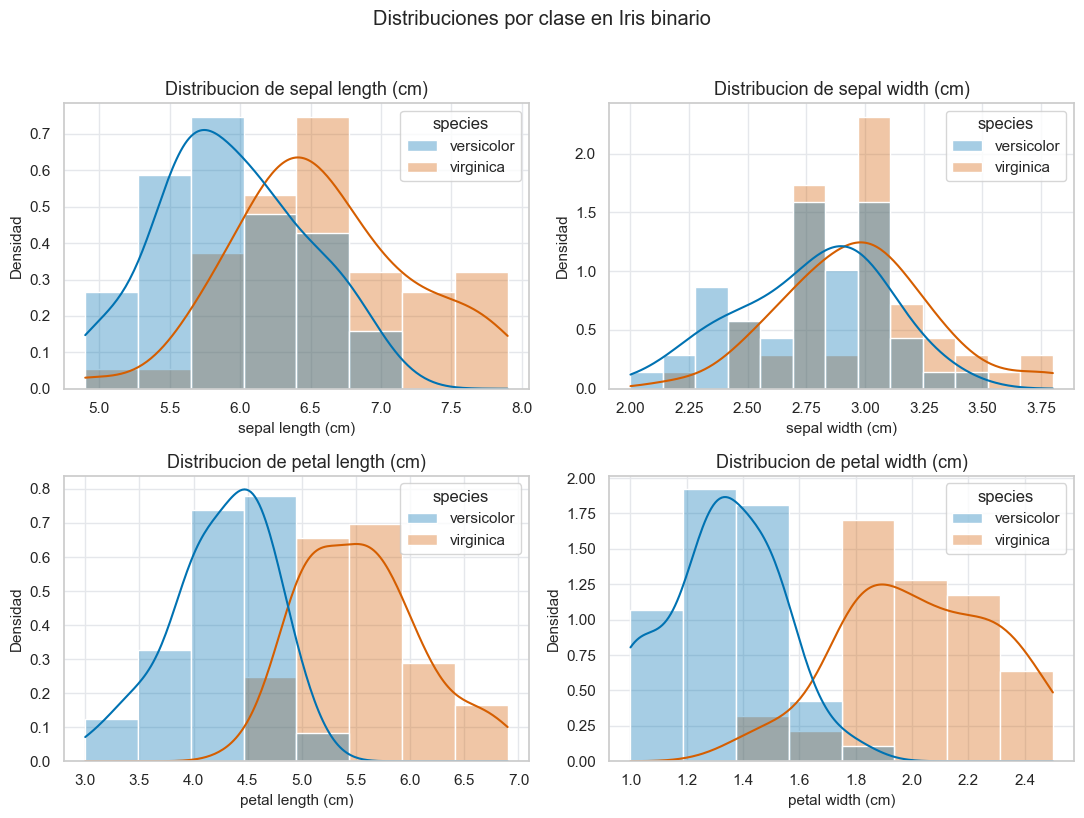

In [4]:
# Dibujamos histogramas con KDE para cada feature. La comparacion por
# clase muestra donde hay separacion clara y donde aun existe traslape.
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()

for ax, feature in zip(axes, X.columns):
    sns.histplot(
        data=iris_binary,
        x=feature,
        hue="species",
        kde=True,
        stat="density",
        common_norm=False,
        alpha=0.35,
        ax=ax,
    )
    ax.set_title(f"Distribucion de {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Densidad")

fig.suptitle("Distribuciones por clase en Iris binario", y=1.02)
fig.tight_layout()
plt.show()


**Interpretacion.** `petal length` y `petal width` desplazan claramente a `virginica` hacia valores mayores, pero las colas se superponen con `versicolor`. Ese traslape evita una clasificacion perfecta y obliga al modelo a producir probabilidades graduadas.


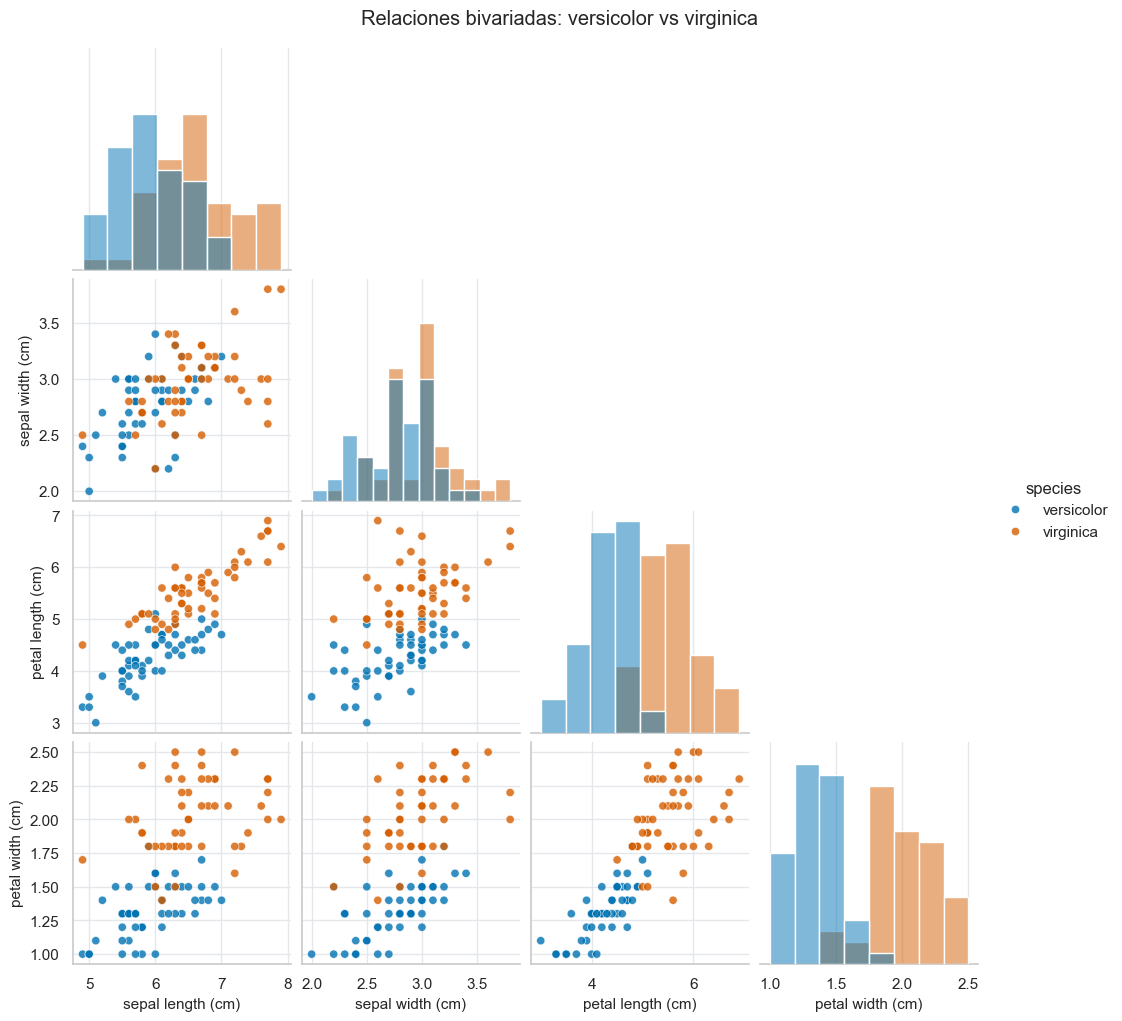

In [5]:
# El pairplot resume relaciones bivariadas. Es especialmente util para
# justificar por que las fronteras 2D se dibujaran con las variables de petalo.
pair_grid = sns.pairplot(
    iris_binary,
    vars=list(X.columns),
    hue="species",
    diag_kind="hist",
    corner=True,
    plot_kws={"alpha": 0.8, "edgecolor": "white", "linewidth": 0.5},
)
pair_grid.fig.suptitle("Relaciones bivariadas: versicolor vs virginica", y=1.02)
plt.show()


**Interpretacion.** El pairplot confirma que las variables de petalo concentran la mayor capacidad discriminativa. Tambien muestra que la separacion no es absoluta: hay puntos cercanos a la frontera, justo el escenario donde la interpretacion probabilistica importa.


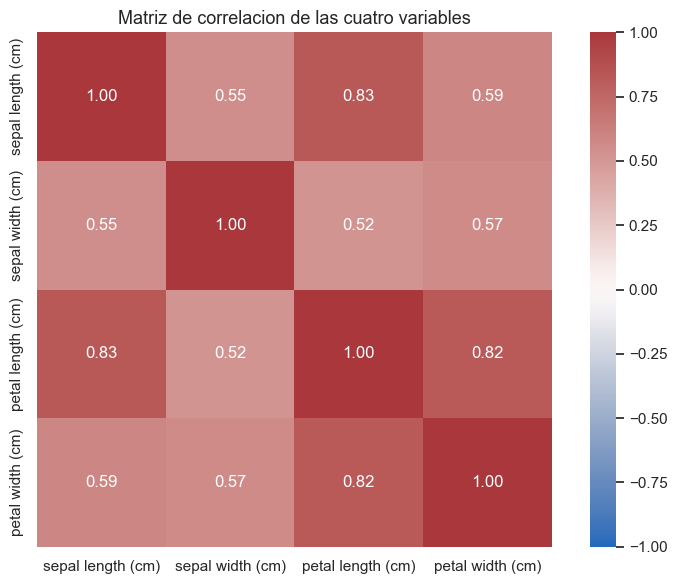

In [6]:
# La matriz de correlacion anticipa el problema de colinealidad:
# variables muy correlacionadas pueden volver inestables los coeficientes.
corr = X.corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
)
ax.set_title("Matriz de correlacion de las cuatro variables")
fig.tight_layout()
plt.show()


**Interpretacion.** La correlacion entre `petal length` y `petal width` es fuerte. En modelos no regularizados eso puede repartir el efecto de forma inestable; en NB04 y NB06 veremos como Ridge y Elastic Net estabilizan o agrupan coeficientes correlacionados.


## 5. Split estratificado y escalado

Seguimos la disciplina aplicada descrita por Hosmer, Lemeshow & Sturdivant (2013): separar datos de entrenamiento y prueba antes de evaluar el modelo. El escalado es esencial para penaltis regularizados, porque L1/L2 penalizan coeficientes y por tanto dependen de la escala de las variables.

**Parametros de preparacion.** Usamos `test_size=0.30` para conservar 70 observaciones en entrenamiento y 30 en prueba; es suficiente para evaluar sin dejar el entrenamiento demasiado pequeno. `random_state=42` fija el sorteo y la funcion helper aplica estratificacion, de modo que ambas particiones mantienen 50% `versicolor` y 50% `virginica`.


In [7]:
# test_size=0.30 crea una particion 70/30: bastante test para evaluar,
# pero suficiente train para estimar coeficientes estables en un dataset pequeno.
# La funcion helper estratifica y StandardScaler se ajusta SOLO con train para evitar leakage.
split_data = get_train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE)

resumen_split = pd.DataFrame(
    {
        "particion": ["train", "test"],
        "n": [len(split_data["y_train"]), len(split_data["y_test"])],
        "proporcion_virginica": [
            split_data["y_train"].mean(),
            split_data["y_test"].mean(),
        ],
    }
)
display(resumen_split.round(3))
display(split_data["X_train_scaled"].describe().round(3))


,particion,n,proporcion_virginica
0,train,70,0.5
1,test,30,0.5


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,70.000,70.000,70.000,70.000
mean,0.000,-0.000,-0.000,0.000
std,1.007,1.007,1.007,1.007
min,-1.981,-2.268,-2.399,-1.602
25%,-0.846,-0.690,-0.743,-0.925
50%,-0.035,-0.059,-0.087,-0.248
75%,0.614,0.573,0.725,0.880
max,2.561,2.782,2.474,1.783


**Interpretacion.** La estratificacion conserva el balance entre clases. Las variables escaladas tienen media cercana a 0 y desviacion cercana a 1 en entrenamiento, lo que hace comparables los coeficientes regularizados.


## 6. Guardado de splits compartidos

Todos los notebooks posteriores cargan estos archivos desde `data/processed/`. Asi evitamos que pequenas diferencias de split contaminen las comparaciones entre modelos.


In [8]:
# Guardamos arrays, nombres de features y parametros del scaler en un NPZ
# pequeno. El archivo queda versionable porque no es un dato pesado.
output_file = save_processed_splits(split_data, DATA_DIR)
print(f"Splits guardados en: {output_file}")


Splits guardados en: C:\Users\memom\GuillermoDriveDocs\GuillermoMM_Everything\Academic_FormationAdd\Code_DS\Play_LogisticReg\play_logistic_Regression\data\processed\iris_binary_splits.npz


## Resumen y conexion con la literatura

Este notebook establecio el contrato de datos del repositorio: `versicolor=0`, `virginica=1`, cuatro variables para modelos completos y `petal length`/`petal width` para fronteras 2D. La decision de explorar, estratificar, escalar y reservar un conjunto de prueba sigue el enfoque aplicado de Hosmer, Lemeshow & Sturdivant (2013), donde la preparacion cuidadosa de datos es parte central de un analisis logistico defendible.
